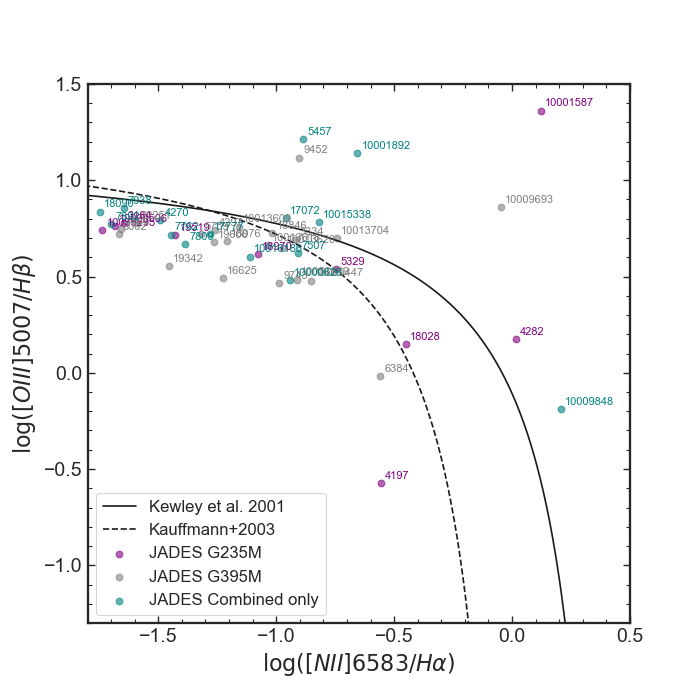

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib widget

#================= Plot Settings =================#
# Latex rendering
#plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
#plt.rc('text', usetex=True)
#plt.rc('font', weight='bold')




# --- Cosmology palette (normalized RGB) ---
COSMO_COLORS = {
    "deep_blue": (30/255, 60/255, 120/255),
    "warm_gold": (200/255, 140/255, 0/255),
    "dark_teal": (0/255, 130/255, 90/255),
    "soft_crimson": (150/255, 40/255, 40/255),
    "cool_gray": (120/255, 120/255, 120/255),
    }

sns.set_theme(
    style="ticks",
    context='talk',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True,
    })

sns.set_palette([
    COSMO_COLORS["deep_blue"],
    "black",
    COSMO_COLORS["warm_gold"],
    COSMO_COLORS["cool_gray"],
    COSMO_COLORS["dark_teal"],
    COSMO_COLORS["soft_crimson"],
    ])

#General Settings
plt.rc('axes', titlesize=16)     # fontsize of the axes title
plt.rc('axes', labelsize=16)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=16)          # controls default text sizes


def plot_bpt_combined(source='MAST', arrows=True, labels=False, save=False, show=True):
    #================= File Reading =================#
    # Read the TSV file
    df_g235m = pd.read_csv('./Output_data/Line_fluxes_g235m_v5_optimal.tsv', sep='\t')
    df_g395m = pd.read_csv('./Output_data/Line_fluxes_g395m_v5_optimal.tsv', sep='\t')
    df_combn = pd.read_csv('./Output_data/Line_fluxes_combined_v5_optimal.tsv', sep='\t')

    if source == 'MAST':
        suffix = 'MAST'
        label_prefix = 'MAST'
        save_name = './Output_data/BPT_diagram_mast.pdf'
    elif source == 'JADES':
        suffix = 'JADES'
        label_prefix = 'JADES'
        save_name = './Output_data/BPT_diagram_jades.pdf'
    else:
        raise ValueError("Source must be 'MAST' or 'JADES'")

    # Create a sub dataframe with ID, redshift, and all columns containing the suffix
    cols_g235m = [col for col in df_g235m.columns if suffix in col]
    df_g235m_sub = df_g235m[['ID', 'redshift'] + cols_g235m].copy()

    cols_g395m = [col for col in df_g395m.columns if suffix in col]
    df_g395m_sub = df_g395m[['ID', 'redshift'] + cols_g395m].copy()

    cols_combn = [col for col in df_combn.columns if suffix in col]
    df_combn_sub = df_combn[['ID', 'redshift'] + cols_combn].copy()

    plot_cols = [
        f'Flux ([OIII]5007) {suffix}',
        f'Flux (Hb 4861) {suffix}',
        f'Flux ([NII]6583) {suffix}',
        f'Flux (Ha 6563) {suffix}',
        f'F_err([NII]6583) {suffix}',
    ]

    # Keep only rows with valid flux measurements in the G235M and G395M plots
    df_g235m_sub = df_g235m_sub.dropna(subset=plot_cols)
    df_g395m_sub = df_g395m_sub.dropna(subset=plot_cols)

    # Only keep combined rows whose IDs are not already in the valid G235M or G395M samples
    existing_ids = pd.Index(df_g235m_sub['ID']).append(pd.Index(df_g395m_sub['ID'])).unique()
    df_combn_only = df_combn_sub[~df_combn_sub['ID'].isin(existing_ids)].copy()

    # Require all four line fluxes for the combined-only sample
    df_combn_only = df_combn_only.dropna(subset=plot_cols)

    # Extract the specific columns of interest
    flux_o3_g235m = df_g235m_sub[f'Flux ([OIII]5007) {suffix}']
    flux_hb_g235m = df_g235m_sub[f'Flux (Hb 4861) {suffix}']
    flux_n2_g235m = df_g235m_sub[f'Flux ([NII]6583) {suffix}']
    flux_ha_g235m = df_g235m_sub[f'Flux (Ha 6563) {suffix}']

    flux_o3_g395m = df_g395m_sub[f'Flux ([OIII]5007) {suffix}']
    flux_hb_g395m = df_g395m_sub[f'Flux (Hb 4861) {suffix}']
    flux_n2_g395m = df_g395m_sub[f'Flux ([NII]6583) {suffix}']
    flux_ha_g395m = df_g395m_sub[f'Flux (Ha 6563) {suffix}']

    ferr_n2_g395m = df_g395m_sub[f'F_err([NII]6583) {suffix}']

    #================= Calculations for the plot =================#
    # Calculate log ratios (x and y for scatter plot)
    y235 = np.log10(flux_o3_g235m / flux_hb_g235m)
    x235 = np.log10(flux_n2_g235m / flux_ha_g235m)

    y395 = np.log10(flux_o3_g395m / flux_hb_g395m)
    x395 = np.log10(flux_n2_g395m / flux_ha_g395m)

    ferr_n2_g235m = df_g235m_sub[f'F_err([NII]6583) {suffix}']
    g235m_left_arrow = flux_n2_g235m < ferr_n2_g235m

    ferr_n2_g395m = df_g395m_sub[f'F_err([NII]6583) {suffix}']
    g395_left_arrow = flux_n2_g395m < ferr_n2_g395m

    flux_o3_combn = df_combn_only[f'Flux ([OIII]5007) {suffix}']
    flux_hb_combn = df_combn_only[f'Flux (Hb 4861) {suffix}']
    flux_n2_combn = df_combn_only[f'Flux ([NII]6583) {suffix}']
    flux_ha_combn = df_combn_only[f'Flux (Ha 6563) {suffix}']
    ferr_n2_combn = df_combn_only[f'F_err([NII]6583) {suffix}']
    combn_left_arrow = flux_n2_combn < ferr_n2_combn

    ycombn = np.log10(flux_o3_combn / flux_hb_combn)
    xcombn = np.log10(flux_n2_combn / flux_ha_combn)

    # Kewley maximum starburst line-
    x_kewly = np.linspace(-2.0, 0.25, 500)
    x_kauff = np.linspace(-2.0, 0., 500)
    y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    #================= plot function =================# 
    plt.figure(figsize=(7, 7))

    plt.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
    plt.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')

    plt.scatter(x235, y235, alpha=0.6, color='purple', label=f'{label_prefix} G235M')
    plt.scatter(x395, y395, alpha=0.6, color='grey', label=f'{label_prefix} G395M')
    plt.scatter(xcombn, ycombn, alpha=0.6, color='teal', label=f'{label_prefix} Combined only')

    plt.xlim(-1.8, 0.5)
    plt.ylim(-1.3, 1.5)
    plt.xlabel(r'$\log([NII]6583/H\alpha)$')
    plt.ylabel(r'$\log([OIII]5007/H\beta)$') 
    plt.minorticks_on()

    #Add arrows of upper limits for [NII]6583 fluxes where the flux is less than the error
    if arrows:
        for x, y in zip(x235[g235m_left_arrow], y235[g235m_left_arrow]):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color='purple', alpha=0.6, lw=2.5, mutation_scale=10),
                va='center'
            )

        for x, y in zip(x395[g395_left_arrow], y395[g395_left_arrow]):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color='grey', lw=2.5, mutation_scale=12),
                va='center'
            )

        for x, y in zip(xcombn[combn_left_arrow], ycombn[combn_left_arrow]):
            plt.annotate(
                '',
                xy=(x - 0.12, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color='teal', lw=2.5, mutation_scale=12),
                va='center'
            )

    if labels:
        for x, y, obj_id in zip(x235, y235, df_g235m_sub['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color='purple'
            )

        for x, y, obj_id in zip(x395, y395, df_g395m_sub['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color='grey'
            )

        for x, y, obj_id in zip(xcombn, ycombn, df_combn_only['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color='teal'
            )

    plt.legend(loc='lower left')
    
    if save:
        plt.savefig(save_name, bbox_inches='tight')
    
    if show:
        plt.show()

#====================================================================#
#====================================================================#
plot_bpt_combined(source='JADES', save=False, labels=True, arrows=False)

#plot_bpt_combined(source='MAST', save=True, labels=False)

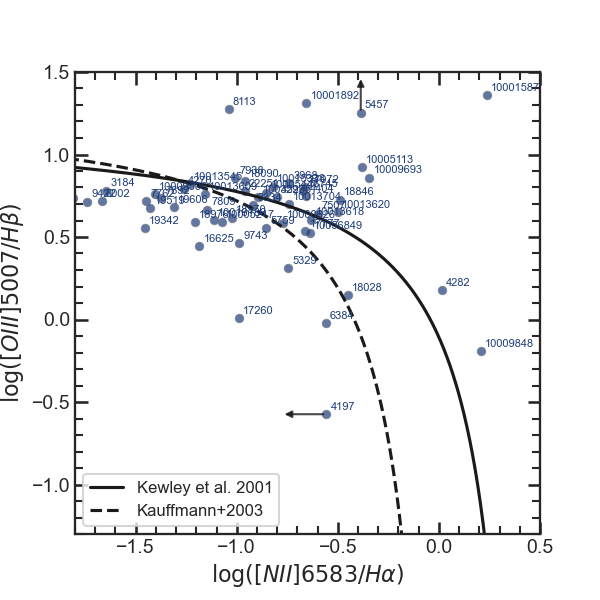

In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import base

%matplotlib widget
#================= Plot Settings =================#
# Latex rendering
#plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
#plt.rc('text', usetex=True)
#plt.rc('font', weight='bold')

# --- Cosmology palette (normalized RGB) ---
COSMO_COLORS = {
    "deep_blue": (30/255, 60/255, 120/255),
    "warm_gold": (200/255, 140/255, 0/255),
    "dark_teal": (0/255, 130/255, 90/255),
    "soft_crimson": (150/255, 40/255, 40/255),
    "cool_gray": (120/255, 120/255, 120/255),
    }

sns.set_theme(
    style="ticks",
    context='talk',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True,
    })

sns.set_palette([
    COSMO_COLORS["deep_blue"],
    "black",
    COSMO_COLORS["warm_gold"],
    COSMO_COLORS["cool_gray"],
    COSMO_COLORS["dark_teal"],
    COSMO_COLORS["soft_crimson"],
    ])

#General Settings
plt.rc('axes', titlesize=16)     # fontsize of the axes title
plt.rc('axes', labelsize=16)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=16)          # controls default text sizes


def compute_axes(source='MAST', filter='G235M', save=False, show=True):
    #================= File Reading =================#
    # Read the TSV file
    df_all = pd.read_csv('./Output_data/Line_fluxes_all_filters.tsv', sep='\t')

    if source == 'MAST':
        suffix = f'MAST {filter}'
        label_prefix = 'MAST'
        save_name = './Output_data/BPT_diagram_mast.pdf'
    elif source == 'JADES':
        suffix = f'JADES {filter}'
        label_prefix = 'JADES'
        save_name = './Output_data/BPT_diagram_jades.pdf'
    

    # Create a sub dataframe with ID, redshift, and all columns containing the suffix
    cols = [col for col in df_all.columns if suffix in col]
    df_sub = df_all[['ID', 'redshift'] + cols].copy()
    
    lines_for_plot = [
        f'Flux ([OIII]5007) {suffix}',
        f'Flux (Hb 4861) {suffix}',
        f'Flux ([NII]6583) {suffix}',
        f'Flux (Ha 6563) {suffix}',
        f'F_err([NII]6583) {suffix}',
    ]

    blue_axis = np.log10(df_sub[f'Flux ([OIII]5007) {suffix}'] / df_sub[f'Flux (Hb 4861) {suffix}'])
    red_axis = np.log10(df_sub[f'Flux ([NII]6583) {suffix}'] / df_sub[f'Flux (Ha 6563) {suffix}'])

    result = {
        'ID': df_sub['ID'],
        'redshift': df_sub['redshift'],
        'blue_axis': blue_axis,
        'red_axis': red_axis,
        'red_err': df_sub[f'Flux ([NII]6583) {suffix}'] < df_sub[f'F_err([NII]6583) {suffix}'],
        'blue_err': df_sub[f'Flux (Hb 4861) {suffix}'] < df_sub[f'F_err(Hb 4861) {suffix}']
    }

    return pd.DataFrame(result)
#====================================================================#
#====================================================================#

def plt_bpt(source='JADES', arrows=True, labels=True, save=False, show=True):

    df_235 = compute_axes(source=source, filter='G235M')
    df_395 = compute_axes(source=source, filter='G395M')
    df_395H = compute_axes(source=source, filter='G395H')

    cols = ['blue_axis', 'red_axis', 'red_err', 'blue_err']
    keys = ['ID', 'redshift']

    # Keep only rows common to all three dataframes 
    base = (
        df_235[keys].merge(df_395[keys], on=keys, how='inner').merge(df_395H[keys], on=keys, how='inner')
    )

    # Align each dataframe to the common keys
    a = base.merge(df_235[keys + cols], on=keys, how='left')
    b = base.merge(df_395[keys + cols], on=keys, how='left')
    c = base.merge(df_395H[keys + cols], on=keys, how='left')

    # Start from common ID/redshift
    df_final = base.copy()
    
    # Priority: df_235 -> df_395 -> df_395H -> NaN
    for col in cols:
        df_final[col] = a[col].combine_first(b[col]).combine_first(c[col])


    # Kewley maximum starburst line-
    x_kewly = np.linspace(-2.0, 0.25, 500)
    x_kauff = np.linspace(-2.0, 0., 500)
    y_kewly = 0.61 / (x_kewly - 0.47) + 1.19
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3

    #=================| plot function |=================# 
    plt.figure(figsize=(6, 6))

    plt.plot(x_kewly, y_kewly, color='k', label='Kewley et al. 2001')
    plt.plot(x_kauff, y_kauff, color='k', linestyle='--', label='Kauffmann+2003')
    
    plt.xlim(-1.8, 0.5)
    plt.ylim(-1.3, 1.5)
    plt.xlabel(r'$\log([NII]6583/H\alpha)$')
    plt.ylabel(r'$\log([OIII]5007/H\beta)$') 
    plt.minorticks_on()
    plt.grid(False)

    xf=df_final['red_axis']
    yf=df_final['blue_axis']


    sns.scatterplot(x=xf, y=yf, s=40, color=COSMO_COLORS['deep_blue'], edgecolor='grey', alpha=0.7)

    if labels:
        for x, y, obj_id in zip(xf, yf, df_final['ID']):
            plt.annotate(
                str(obj_id),
                (x, y),
                textcoords="offset points",
                xytext=(3, 3),
                ha="left",
                fontsize=8,
                color=COSMO_COLORS['deep_blue']
            )

    
    
    if arrows:
        for x, y in zip(xf[df_final['red_err']], yf[df_final['red_err']] ):
            plt.annotate(
                '',
                xy=(x - 0.22, y),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color='k', alpha=0.8, lw=1.5, mutation_scale=10),
                va='center'
            )

        
        for x, y in zip(xf[df_final['blue_err']], yf[df_final['blue_err']] ):
            plt.annotate(
                '',
                xy=(x, y+0.22),
                xytext=(x, y),
                arrowprops=dict(arrowstyle='-|>', color='k', alpha=0.8, lw=1.5, mutation_scale=10),
                va='center'
            )
    
    
    if save:
        plt.savefig('bpt_v2.pdf', bbox_inches='tight')

    if show:
        plt.show()


plt_bpt(labels=True, arrows=True, show=False)